# ARB Tactical Brain — Calibrated Isolation Forest
**Purpose:** Train an Isolation Forest exclusively on nominal baseline data,
then run it across the full mission timeline to detect structural breaks
(tumbles, power shorts, CPU lockups).

Key design choices:
- **Nominal Gate** – scaler and model are fitted *only* on healthy epochs
- **1% contamination** – hunts for massive structural breaks, ignores tiny jitter
- **Continuous anomaly score** – `score_samples()` drives the SUSPICIOUS/ARMED split
- **3-epoch debounce** – requires three consecutive anomalous readings before firing


In [ ]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Path resolution (works on any machine)
BASE_DIR   = Path().resolve().parent          # project root
DATA_DIR   = BASE_DIR / "Data"
MODELS_DIR = BASE_DIR / "src" / "trained_models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data   : {DATA_DIR}")
print(f"Models : {MODELS_DIR}")


Data   : /home/efob/Documents/Codes/AESH/Data
Models : /home/efob/Documents/Codes/AESH/src/trained_models


## 1 — Load telemetry dataset

In [3]:
csv_path = DATA_DIR / "arb_telemetry_dataset.csv"
df = pd.read_csv(csv_path)
print(f"Loaded {len(df)} epochs from '{csv_path}'")

# Ground-truth strike time (for evaluation only — the AI never sees labels)
labeled_anomalies  = df[df['Target_Status'] == 'ANOMALY']
actual_strike_time = labeled_anomalies['Epoch'].iloc[0] if not labeled_anomalies.empty else None
print(f"Ground-truth disaster starts at: Epoch {actual_strike_time}")
df.head()


Loaded 2000 epochs from '/home/efob/Documents/Codes/AESH/Data/arb_telemetry_dataset.csv'
Ground-truth disaster starts at: Epoch 517


,Epoch,Host_Propellant_PSI,Host_Bus_Voltage,Host_Heartbeat_ms,ARB_Gyro_Mag,ARB_Temp_C,Target_Status
0,1,299.48,28.37,16,0.010,16.24,Nominal
1,2,300.37,28.59,15,0.014,16.22,Nominal
2,3,300.45,28.55,19,0.013,14.55,Nominal
3,4,298.99,28.22,17,0.005,15.19,Nominal
4,5,299.31,28.72,14,0.013,13.14,Nominal


## 2 — Feature extraction & nominal gate
The scaler is fitted **strictly on nominal rows** so anomalous variance
never pollutes the baseline mean/std estimates.


In [4]:
FEATURES     = ['Host_Propellant_PSI', 'Host_Bus_Voltage',
                'Host_Heartbeat_ms',   'ARB_Gyro_Mag', 'ARB_Temp_C']
nominal_mask = df['Target_Status'] == 'Nominal'

print(f"Nominal epochs available for fitting: {nominal_mask.sum()}")

scaler = StandardScaler()
scaler.fit(df.loc[nominal_mask, FEATURES])          # fit on nominal only
X_scaled = scaler.transform(df[FEATURES])           # transform entire timeline

# Persist the frozen scaler
scaler_path = MODELS_DIR / "sensor_scaler.pkl"
joblib.dump(scaler, scaler_path)
print(f"Scaler saved → {scaler_path}")


Nominal epochs available for fitting: 516
Scaler saved → /home/efob/Documents/Codes/AESH/src/trained_models/sensor_scaler.pkl


## 3 — Train Isolation Forest on nominal baseline
`contamination=0.01` tells the forest to treat 1 % of training samples
as outliers, which calibrates the decision threshold without exposing the
model to actual disaster data.


In [5]:
ai = IsolationForest(n_estimators=200, contamination=0.01, random_state=42)
ai.fit(X_scaled[nominal_mask])

tactical_path = MODELS_DIR / "tactical_brain.pkl"
joblib.dump(ai, tactical_path)
print(f"Tactical Brain saved → {tactical_path}")


Tactical Brain saved → /home/efob/Documents/Codes/AESH/src/trained_models/tactical_brain.pkl


## 4 — Run inference across the full mission timeline
`predict()` returns binary labels (+1 nominal, -1 anomaly).
`score_samples()` returns a **continuous anomaly score**; more negative
values are further from the nominal cluster and map to the ARMED state,
while scores close to zero map to the milder SUSPICIOUS state.


In [ ]:
df['AI_Anomaly_Signal'] = ai.predict(X_scaled)
df['Anomaly_Score']     = ai.score_samples(X_scaled)   # continuous score

# 3-epoch debounce persistence filter
calibration_window = int(len(df) * 0.20)
df['Is_Anomaly'] = np.where(
    (df['AI_Anomaly_Signal'] == -1) & (df['Epoch'] > calibration_window), 1, 0
)
df['Anomaly_Streak'] = df['Is_Anomaly'].rolling(window=3).sum()

confirmed = df[df['Anomaly_Streak'] == 3]
ai_trigger_time = confirmed['Epoch'].iloc[0] if not confirmed.empty else None

# Evaluation
print("=" * 55)
if ai_trigger_time and actual_strike_time:
    delay = ai_trigger_time - actual_strike_time
    print(f"ACTUAL DISASTER START : Epoch {actual_strike_time}")
    print(f"AI AUTONOMOUS TRIGGER : Epoch {ai_trigger_time}  (response: {delay:+d} min)")
    if 0 <= delay <= 5:
        print("RATING: FLAWLESS — disaster verified before unrecoverable tumble.")
    elif delay > 5:
        print("RATING: SLOW — consider lowering contamination or debounce window.")
    else:
        print("RATING: FALSE ALARM — AI triggered before the disaster occurred.")
else:
    print("RATING: FAILED — AI missed the disaster entirely.")
print("=" * 55)


ACTUAL DISASTER START : Epoch 517
AI AUTONOMOUS TRIGGER : Epoch 519  (response: +2 min)
RATING: FLAWLESS — disaster verified before unrecoverable tumble.


## 5 — Mission Control dashboard with anomaly score subplot

/tmp/ipykernel_25009/3711484258.py:51: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


Dashboard saved → '/home/efob/Documents/Codes/AESH/Data/isolation_forest_bulletproof.png'


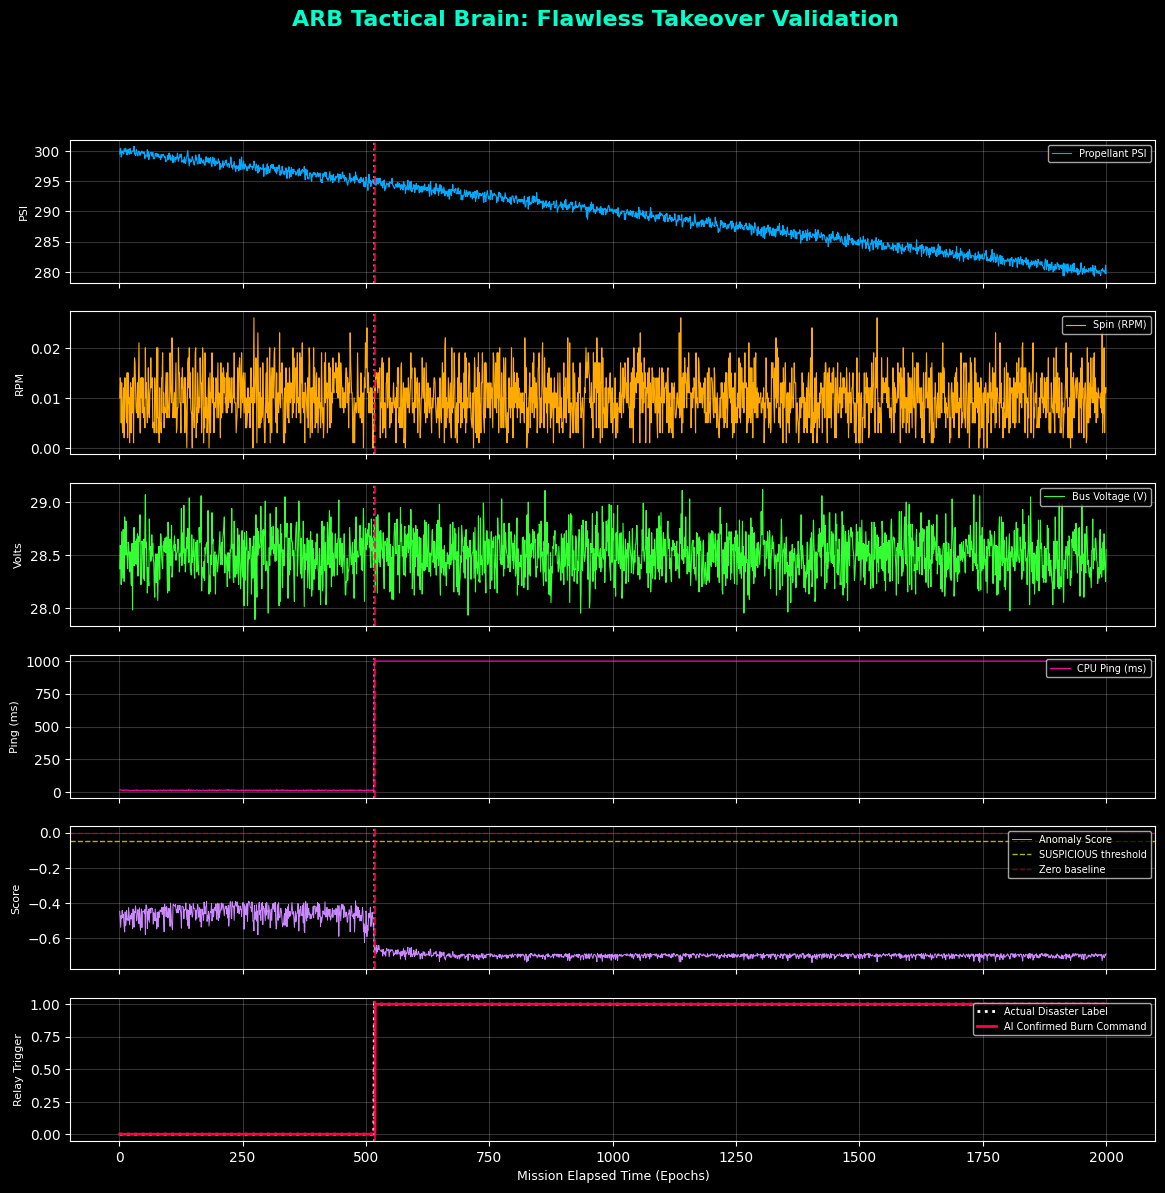

In [7]:
plt.style.use('dark_background')
fig, axes = plt.subplots(6, 1, figsize=(14, 13), sharex=True)
fig.suptitle('ARB Tactical Brain: Flawless Takeover Validation',
             fontsize=16, fontweight='bold', color='#00ffcc')

# Sensor panels
panels = [
    ('Host_Propellant_PSI', 'PSI',      '#00aaff', 'Propellant PSI'),
    ('ARB_Gyro_Mag',        'RPM',      '#ffaa00', 'Spin (RPM)'),
    ('Host_Bus_Voltage',    'Volts',    '#33ff33', 'Bus Voltage (V)'),
    ('Host_Heartbeat_ms',   'Ping (ms)','#ff00aa', 'CPU Ping (ms)'),
]
for ax, (col, ylabel, color, label) in zip(axes[:4], panels):
    ax.plot(df['Epoch'], df[col], color=color, lw=0.8, label=label)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.legend(loc='upper right', fontsize=7)
    ax.grid(True, alpha=0.2)

# Continuous anomaly score panel (new)
axes[4].plot(df['Epoch'], df['Anomaly_Score'], color='#cc88ff', lw=0.7, label='Anomaly Score')
axes[4].axhline(y=-0.05, color='yellow',  linestyle='--', lw=1, alpha=0.7, label='SUSPICIOUS threshold')
axes[4].axhline(y=0,     color='#ff0044', linestyle='--', lw=1, alpha=0.5, label='Zero baseline')
axes[4].set_ylabel('Score', fontsize=8)
axes[4].legend(loc='upper right', fontsize=7)
axes[4].grid(True, alpha=0.2)

# Relay trigger panel
disaster_line = np.where(df['Target_Status'] == 'ANOMALY', 1, 0)
axes[5].plot(df['Epoch'], disaster_line, color='white', linestyle=':', lw=2, label='Actual Disaster Label')
trigger_line  = np.where(df['Epoch'] >= (ai_trigger_time or 999999), 1, 0)
axes[5].plot(df['Epoch'], trigger_line, color='#ff0044', lw=2, label='AI Confirmed Burn Command')
axes[5].set_ylabel('Relay Trigger', fontsize=8)
axes[5].set_xlabel('Mission Elapsed Time (Epochs)', fontsize=9)
axes[5].legend(loc='upper right', fontsize=7)
axes[5].grid(True, alpha=0.2)

# Vertical markers on every panel
for ax in axes:
    if actual_strike_time:
        ax.axvline(x=actual_strike_time, color='white',   linestyle=':', lw=1.5, alpha=0.5)
    if ai_trigger_time:
        ax.axvline(x=ai_trigger_time,    color='#ff0044', linestyle='--', lw=1.5, alpha=0.8)

if ai_trigger_time and actual_strike_time:
    axes[0].text(
        ai_trigger_time + 15, axes[0].get_ylim()[1] * 0.8,
        f'VERIFIED FIRE: {ai_trigger_time}\n({delay:+d} min)',
        color='#ff0044', fontweight='bold', fontsize=8
    )

plt.tight_layout()

plot_path = DATA_DIR / 'isolation_forest_bulletproof.png'
plt.savefig(plot_path, dpi=300)
print(f"Dashboard saved → '{plot_path}'")
plt.show()
